In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [71]:
df1=pd.read_csv(r"C:\Users\manas\Mutual_Fund_Project/data/raw/01_fund_master.csv")
df2= pd.read_csv(r"C:\Users\manas\Mutual_Fund_Project/data/raw/02_nav_history.csv")
df3= pd.read_csv(r"C:\Users\manas\Mutual_Fund_Project/data/raw/03_aum_by_fund_house.csv")
df10= pd.read_csv(r"C:\Users\manas\Mutual_Fund_Project/data/raw/10_benchmark_indices.csv")
df10

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15
...,...,...,...
8045,2026-05-25,CRISIL_GILT,2278.26
8046,2026-05-26,CRISIL_GILT,2281.42
8047,2026-05-27,CRISIL_GILT,2281.30
8048,2026-05-28,CRISIL_GILT,2298.35


In [36]:
df1.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
28,101206,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.60,1.0,500,1000,Mahesh Patil,Moderate,EC01
30,101208,Aditya Birla Sun Life MF,ABSL Liquid Fund - Regular - Growth,Debt,Liquid,Regular,2000-04-17,CRISIL Liquid Fund AI Index,0.79,0.0,500,5000,Maneesh Dangi,Low,DC01
29,101207,Aditya Birla Sun Life MF,ABSL Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-05-31,BSE 250 SmallCap TRI,1.53,1.0,500,1000,Mircea Ciobanu,Very High,EC03
25,119093,Axis Mutual Fund,Axis Bluechip Fund - Direct - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.75,1.0,500,1000,Shreyash Devalkar,Moderate,EC01
24,119092,Axis Mutual Fund,Axis Bluechip Fund - Regular - Growth,Equity,Large Cap,Regular,2010-01-05,NIFTY 100 TRI,1.64,1.0,500,1000,Shreyash Devalkar,Moderate,EC01


In [35]:
df2.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [75]:
# df3.head()

In [44]:
dfm=pd.merge(df2,df1,on='amfi_code')
dfm


,amfi_code,date,nav,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,2022-01-03,54.3856,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119551,2022-01-04,54.3474,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119551,2022-01-05,54.6869,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
3,119551,2022-01-06,55.4550,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
4,119551,2022-01-07,55.3692,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45995,149324,2026-05-25,292.4810,DSP Mutual Fund,DSP Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-06-14,BSE 250 SmallCap TRI,1.52,1.0,500,1000,Vinit Sambre,Very High,EC03
45996,149324,2026-05-26,291.2707,DSP Mutual Fund,DSP Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-06-14,BSE 250 SmallCap TRI,1.52,1.0,500,1000,Vinit Sambre,Very High,EC03
45997,149324,2026-05-27,288.8007,DSP Mutual Fund,DSP Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-06-14,BSE 250 SmallCap TRI,1.52,1.0,500,1000,Vinit Sambre,Very High,EC03
45998,149324,2026-05-28,280.6873,DSP Mutual Fund,DSP Small Cap Fund - Regular - Growth,Equity,Small Cap,Regular,2007-06-14,BSE 250 SmallCap TRI,1.52,1.0,500,1000,Vinit Sambre,Very High,EC03


In [56]:
dfm["date"]=pd.to_datetime(dfm["date"])
dfm=dfm.sort_values(['scheme_name','date'])
dfm['daily_return']=dfm.groupby('scheme_name')['nav'].pct_change()

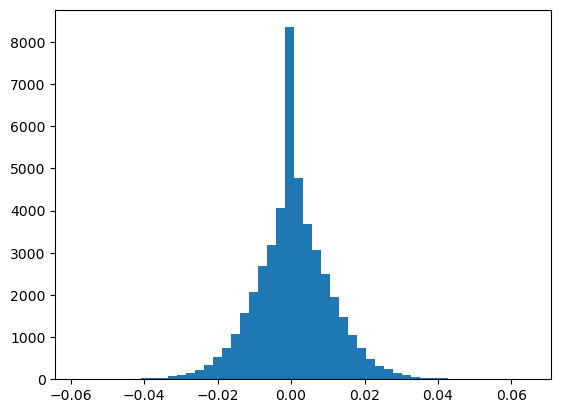

In [57]:
plt.hist(dfm["daily_return"].dropna(),bins=50)
plt.show()

In [59]:
result=[]

for scheme,group in dfm.groupby("scheme_name"):

    start=group.iloc[0]["nav"]

    end=group.iloc[-1]["nav"]

    years=(group["date"].max()-group["date"].min()).days/365

    cagr=((end/start)**(1/years))-1

    result.append([scheme,cagr])

cagr_dfm=pd.DataFrame(result,columns=["scheme_name","cagr"])

In [67]:
rf=0.065

sharpe=[]

for scheme,group in dfm.groupby("scheme_name"):

    r=group["daily_return"].dropna()

    annual_return=r.mean()*252

    annual_std=r.std()*np.sqrt(252)

    sharpe_ratio=(annual_return-rf)/annual_std

    sharpe.append([scheme,sharpe_ratio])

sharpe_df=pd.DataFrame(sharpe,columns=["scheme_name","Sharpe"])

In [83]:
negative=r[r<0]

downside_std=negative.std()*np.sqrt(252)

sortino=(annual_return-rf)/downside_std

In [85]:
def max_drawdown(nav):
    roll_max = nav.cummax()
    drawdown = nav / roll_max - 1
    return drawdown.min()

mdd = dfm.groupby('scheme_name')['nav'].apply(max_drawdown)

In [69]:
from scipy.stats import linregress

In [73]:
df10["date"] = pd.to_datetime(df10["date"])

df10 = df10.sort_values("date")

df10["index_name"] = df2["nav"].pct_change()

In [77]:
merged = pd.merge(
    dfm,
    df10[["date", "index_name"]],
    on="date",
    how="inner"
)

In [78]:
alpha_beta = []

for scheme, group in merged.groupby("scheme_name"):

    group = group.dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        group["index_name"],
        group["daily_return"]
    )

    beta = slope
    alpha = intercept * 252

    alpha_beta.append([scheme, alpha, beta])

In [80]:
alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=["Scheme", "Alpha", "Beta"]
)

alpha_beta_df.head()

,Scheme,Alpha,Beta
0,ABSL Frontline Equity Fund - Regular - Growth,0.214405,0.001606
1,ABSL Liquid Fund - Regular - Growth,0.060874,-0.000032
2,ABSL Small Cap Fund - Regular - Growth,0.105328,0.010866
3,Axis Bluechip Fund - Direct - Growth,0.082571,0.003681
4,Axis Bluechip Fund - Regular - Growth,0.068701,0.003944


In [82]:
alpha_beta_df.to_csv(r"C:\Users\manas\Mutual_Fund_Project/data/raw/alpha_beta.csv", index=False)

In [86]:
scorecard = pd.DataFrame({
    'CAGR': cagr,
    'Sharpe': sharpe,
    'MDD': mdd
})

scorecard['rank'] = (
    0.3 * scorecard['CAGR'].rank() +
    0.25 * scorecard['Sharpe'].rank() +
    0.1 * scorecard['MDD'].rank(ascending=False)
)

In [88]:
scorecard.to_csv("fund_scorecard.csv")


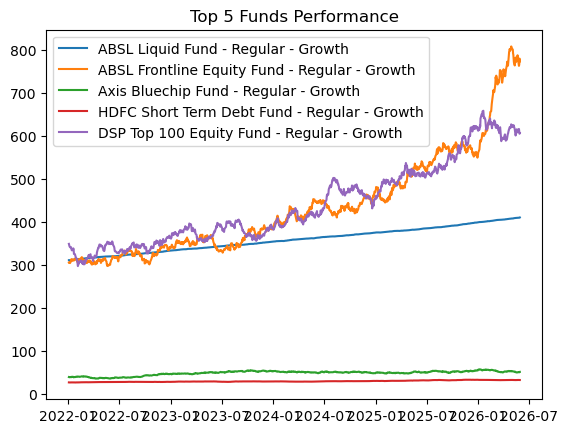

In [90]:

top5 = scorecard.sort_values('rank').head(5).index

for fund in top5:
    temp = dfm[dfm['scheme_name'] == fund]
    plt.plot(temp['date'], temp['nav'], label=fund)

plt.legend()
plt.title("Top 5 Funds Performance")
plt.savefig("chart.png")
plt.show()